In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv(r'C:\Users\anikh\OneDrive\Desktop\preventive-care-gaps\data\processed\meps_2022_clean.csv')

print("Shape:", df.shape)
print("\nPreventive care rate:", df['received_any_preventive'].mean().round(3))
print("\nIncome tier counts:")
print(df['income_tier'].value_counts())

Shape: (17909, 24)

Preventive care rate: 0.91

Income tier counts:
income_tier
High Income\n(400%+)         7040
Middle Income\n(200-399%)    4985
Poor\n(<100% FPL)            2743
Low Income\n(125-199%)       2344
Near Poor\n(100-124%)         797
Name: count, dtype: int64


In [2]:
# Visual 1: Preventive care rate by income tier
# Eligible adults only (non-NaN outcome)
eligible = df[df['received_any_preventive'].notna()].copy()

# Define income tier order (low to high)
income_order = [
    'Poor\n(<100% FPL)',
    'Near Poor\n(100-124%)',
    'Low Income\n(125-199%)',
    'Middle Income\n(200-399%)',
    'High Income\n(400%+)'
]

# Calculate care rate by income tier
income_rates = (eligible.groupby('income_tier')['received_any_preventive']
                .mean()
                .reindex(income_order)
                .reset_index())
income_rates.columns = ['income_tier', 'care_rate']
income_rates['gap_rate'] = 1 - income_rates['care_rate']

print(income_rates)

                 income_tier  care_rate  gap_rate
0          Poor\n(<100% FPL)   0.853926  0.146074
1      Near Poor\n(100-124%)   0.894000  0.106000
2     Low Income\n(125-199%)   0.887268  0.112732
3  Middle Income\n(200-399%)   0.889984  0.110016
4       High Income\n(400%+)   0.952381  0.047619


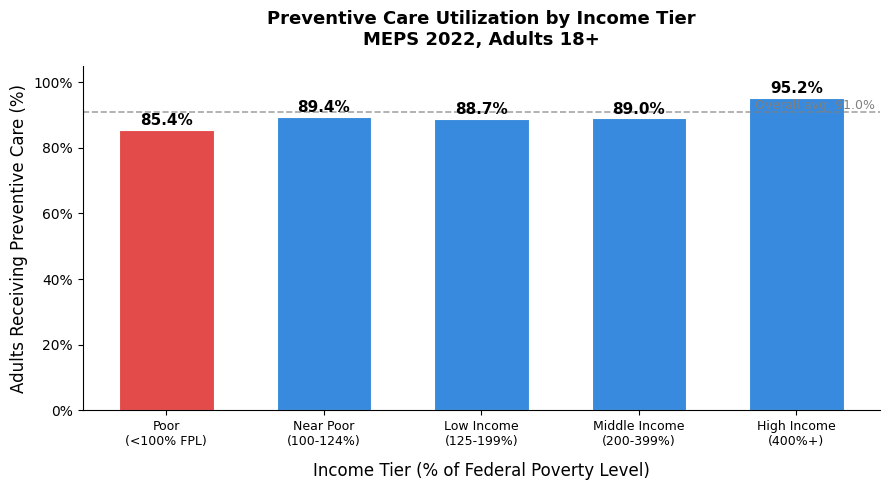

Saved.


In [3]:
# Visual 1: Preventive care rate by income tier
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#E24B4A' if x == income_order[0] else '#378ADD' 
          for x in income_order]

bars = ax.bar(income_order, income_rates['care_rate'] * 100,
              color=colors, width=0.6, edgecolor='white', linewidth=0.8)

# Add value labels on top of each bar
for bar, rate in zip(bars, income_rates['care_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{rate:.1%}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Formatting
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Income Tier (% of Federal Poverty Level)', fontsize=12, labelpad=10)
ax.set_ylabel('Adults Receiving Preventive Care (%)', fontsize=12)
ax.set_title('Preventive Care Utilization by Income Tier\nMEPS 2022, Adults 18+',
             fontsize=13, fontweight='bold', pad=15)
ax.axhline(y=eligible['received_any_preventive'].mean() * 100,
           color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(4.5, eligible['received_any_preventive'].mean() * 100 + 0.8,
        f'Overall avg: {eligible["received_any_preventive"].mean():.1%}',
        ha='right', fontsize=9, color='gray')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()

# Save
output_path = r'C:\Users\anikh\OneDrive\Desktop\preventive-care-gaps\outputs\figures\fig1_care_rate_by_income.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Visual 2: Heat map — care gap by race/ethnicity x insurance status

eligible = df[df['received_any_preventive'].notna()].copy()

# Small insurance categories for a cleaner chart
insurance_recode = {
    'Private': 'Private',
    'Public Only': 'Public Only',
    'Medicare Only': 'Medicare',
    'Medicare + Private': 'Medicare',
    'Medicare + Public': 'Medicare',
    'Other Public': 'Public Only',
    'Uninsured': 'Uninsured'
}
eligible['insurance_simple'] = eligible['insurance_cat'].map(insurance_recode)

race_order = ['NH White', 'NH Black', 'Hispanic', 'NH Asian', 'NH Other']
insurance_order = ['Private', 'Public Only', 'Medicare', 'Uninsured']

# Pivot table: rows = race, columns = insurance, values = gap rate
pivot = (eligible.groupby(['race_eth', 'insurance_simple'])['received_any_preventive']
         .mean()
         .rsub(1)  # 1 - care_rate = gap_rate
         .unstack('insurance_simple')
         .reindex(index=race_order, columns=insurance_order))

print("Care gap rate by race x insurance:")
print(pivot.round(3))

Care gap rate by race x insurance:
insurance_simple  Private  Public Only  Medicare  Uninsured
race_eth                                                   
NH White            0.061        0.064     0.042      0.029
NH Black            0.145        0.117     0.115      0.154
Hispanic            0.131        0.159     0.313      0.214
NH Asian            0.074        0.090     0.129      0.400
NH Other            0.097        0.109     0.131      0.000


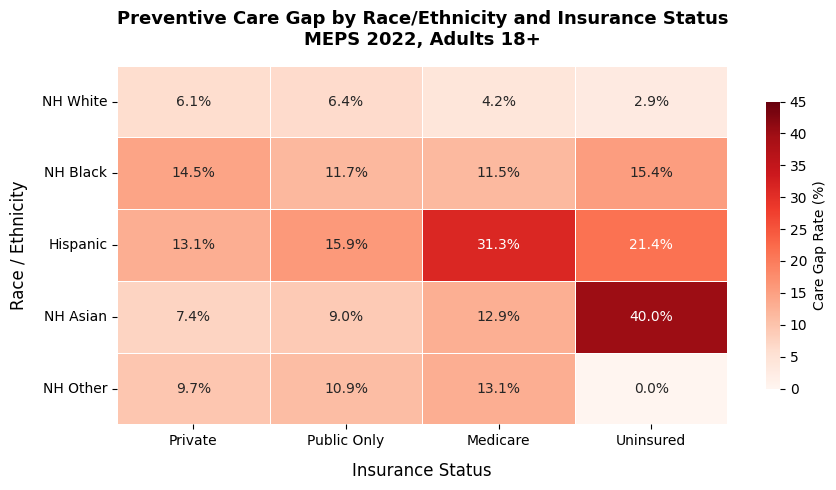

Saved.


In [5]:
# Visual 2: Heat map
fig, ax = plt.subplots(figsize=(9, 5))

# Plot heatmap — higher gap = darker red
sns.heatmap(pivot * 100,
            annot=True,
            fmt='.1f',
            cmap='Reds',
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'Care Gap Rate (%)', 'shrink': 0.8},
            vmin=0, vmax=45)

for text in ax.texts:
    text.set_text(text.get_text() + '%')

ax.set_title('Preventive Care Gap by Race/Ethnicity and Insurance Status\nMEPS 2022, Adults 18+',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Insurance Status', fontsize=12, labelpad=10)
ax.set_ylabel('Race / Ethnicity', fontsize=12, labelpad=10)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10, rotation=0)

plt.tight_layout()

output_path = r'C:\Users\anikh\OneDrive\Desktop\preventive-care-gaps\outputs\figures\fig2_heatmap_race_insurance.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Visual 3: Horizontal bar — % who delayed care due to cost by insurance type
# Filter to people with non-NaN delayed_care_cost
delay_df = df[df['delayed_care_cost'].notna()].copy()
delay_df['insurance_simple'] = delay_df['insurance_cat'].map(insurance_recode)

insurance_order_delay = ['Private', 'Public Only', 'Medicare', 'Uninsured']

delay_rates = (delay_df.groupby('insurance_simple')['delayed_care_cost']
               .mean()
               .reindex(insurance_order_delay)
               .reset_index())
delay_rates.columns = ['insurance_simple', 'delay_rate']

print(delay_rates)

  insurance_simple  delay_rate
0          Private    0.072258
1      Public Only    0.064022
2         Medicare    0.068084
3        Uninsured    0.073394


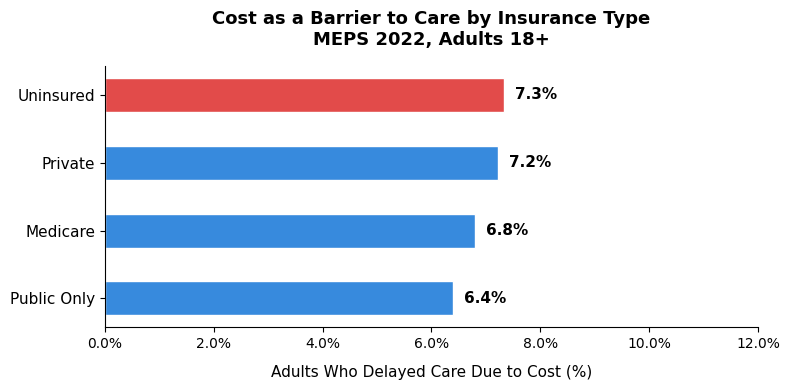

In [7]:
# Visual 3: Horizontal bar — % delayed care due to cost by insurance type
fig, ax = plt.subplots(figsize=(8, 4))

# Reverse order so highest bar is at top
plot_df = delay_rates.sort_values('delay_rate', ascending=True)

colors = ['#E24B4A' if x == 'Uninsured' else '#378ADD' 
          for x in plot_df['insurance_simple']]

bars = ax.barh(plot_df['insurance_simple'],
               plot_df['delay_rate'] * 100,
               color=colors, height=0.5, edgecolor='white')

for bar, rate in zip(bars, plot_df['delay_rate']):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{rate:.1%}',
            va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Adults Who Delayed Care Due to Cost (%)', fontsize=11, labelpad=10)
ax.set_title('Cost as a Barrier to Care by Insurance Type\nMEPS 2022, Adults 18+',
             fontsize=13, fontweight='bold', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()

output_path = r'C:\Users\anikh\OneDrive\Desktop\preventive-care-gaps\outputs\figures\fig3_delayed_care_by_insurance.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Visual 4: Preventive care rate by age group
eligible = df[df['received_any_preventive'].notna()].copy()

# Create age groups
bins = [18, 35, 50, 65, 85]
labels = ['18–34', '35–49', '50–64', '65+']
eligible['age_group'] = pd.cut(eligible['AGE22X'], bins=bins, 
                                labels=labels, right=True)

# Calculate rates
age_rates = (eligible.groupby('age_group', observed=True)['received_any_preventive']
             .agg(['mean', 'count'])
             .reset_index())
age_rates.columns = ['age_group', 'care_rate', 'n']
age_rates['gap_rate'] = 1 - age_rates['care_rate']

print(age_rates)

  age_group  care_rate     n  gap_rate
0     18–34   0.790531  2091  0.209469
1     35–49   0.871637  2267  0.128363
2     50–64   0.936606  3076  0.063394
3       65+   0.978415  3799  0.021585


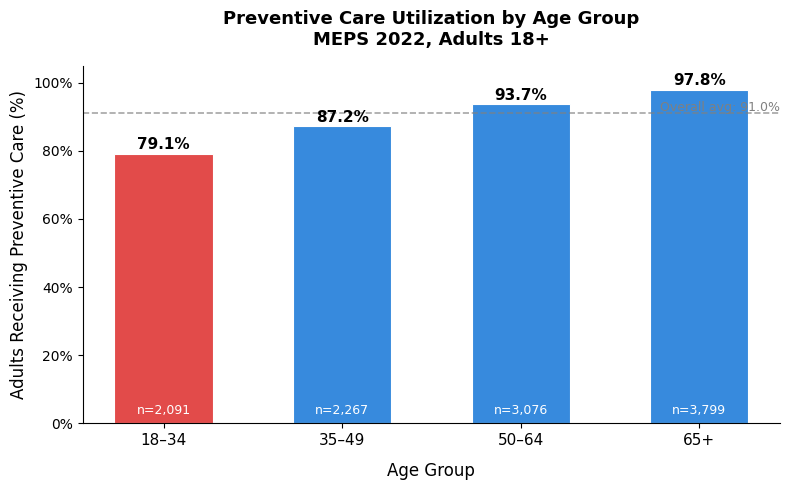

In [9]:
# Visual 4: Preventive care rate by age group
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#E24B4A' if x == '18–34' else '#378ADD' 
          for x in age_rates['age_group']]

bars = ax.bar(age_rates['age_group'],
              age_rates['care_rate'] * 100,
              color=colors, width=0.55,
              edgecolor='white', linewidth=0.8)

# Value labels
for bar, rate, n in zip(bars, age_rates['care_rate'], age_rates['n']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{rate:.1%}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width() / 2,
            2,
            f'n={n:,}',
            ha='center', va='bottom', fontsize=9, color='white')

# Overall average line
avg = eligible['received_any_preventive'].mean()
ax.axhline(y=avg * 100, color='gray', linestyle='--',
           linewidth=1.2, alpha=0.7)
ax.text(3.45, avg * 100 + 0.6,
        f'Overall avg: {avg:.1%}',
        ha='right', fontsize=9, color='gray')

ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Age Group', fontsize=12, labelpad=10)
ax.set_ylabel('Adults Receiving Preventive Care (%)', fontsize=12)
ax.set_title('Preventive Care Utilization by Age Group\nMEPS 2022, Adults 18+',
             fontsize=13, fontweight='bold', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=11)

plt.tight_layout()

output_path = r'C:\Users\anikh\OneDrive\Desktop\preventive-care-gaps\outputs\figures\fig4_care_rate_by_age.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()